In [1]:
from train_BERT_classifier import load_classifier
from pathlib import Path
import pickle
import matplotlib.pyplot as plt

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/yajatyadav/multitask_reinforcement_learning/multitask_RL/.venv/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [3]:
root_path = '/home/yajatyadav/multitask_reinforcement_learning/checkpoints/CLASSIFIERS/libero_90_all_tasks_classifier'
plot_data = Path(root_path) / 'plotting_data.pkl'
with open(plot_data, 'rb') as f:
    plot_data = pickle.load(f)

# Training Plots

In [9]:
print(plot_data.keys())
print(len(plot_data['per_task_val_losses']), len(plot_data['per_task_val_accuracies']))
# pick arbitrary task and count
k = list(plot_data['per_task_val_losses'].keys())[0]
print(len(plot_data['per_task_val_losses'][k]), len(plot_data['per_task_val_accuracies'][k]))
print(len(plot_data['train_losses']), len(plot_data['val_losses']))
print(len(plot_data['grad_max']), len(plot_data['grad_min']), len(plot_data['grad_norm']))

dict_keys(['train_losses', 'val_losses', 'val_accuracies', 'per_task_val_losses', 'per_task_val_accuracies', 'grad_max', 'grad_min', 'grad_norm'])
90 90
525 525
13100 525
13100 13100 13100


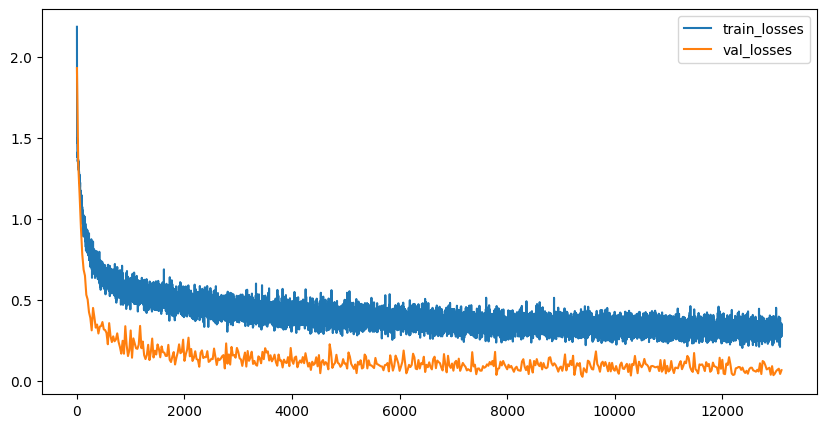

In [10]:
# plot train_losses and grad
plt.figure(figsize=(10, 5))
train_data = plot_data['train_losses']
train_x = [x[0] for x in train_data]
train_y = [x[1] for x in train_data]
val_x = [x[0] for x in plot_data['val_losses']]
val_y = [x[1] for x in plot_data['val_losses']]
plt.plot(train_x, train_y, label='train_losses')
plt.plot(val_x, val_y, label='val_losses')
plt.legend()
plt.show()

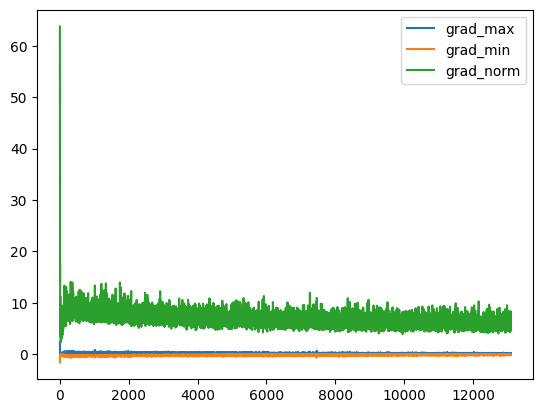

In [11]:
grad_max = plot_data['grad_max']
grad_min = plot_data['grad_min']
grad_norm = plot_data['grad_norm']
grad_x_vals = [x[0] for x in grad_norm]
plt.plot(grad_x_vals, [x[1] for x in grad_max], label='grad_max')
plt.plot(grad_x_vals, [x[1] for x in grad_min], label='grad_min')
plt.plot(grad_x_vals, [x[1] for x in grad_norm], label='grad_norm')
plt.legend()
plt.show()

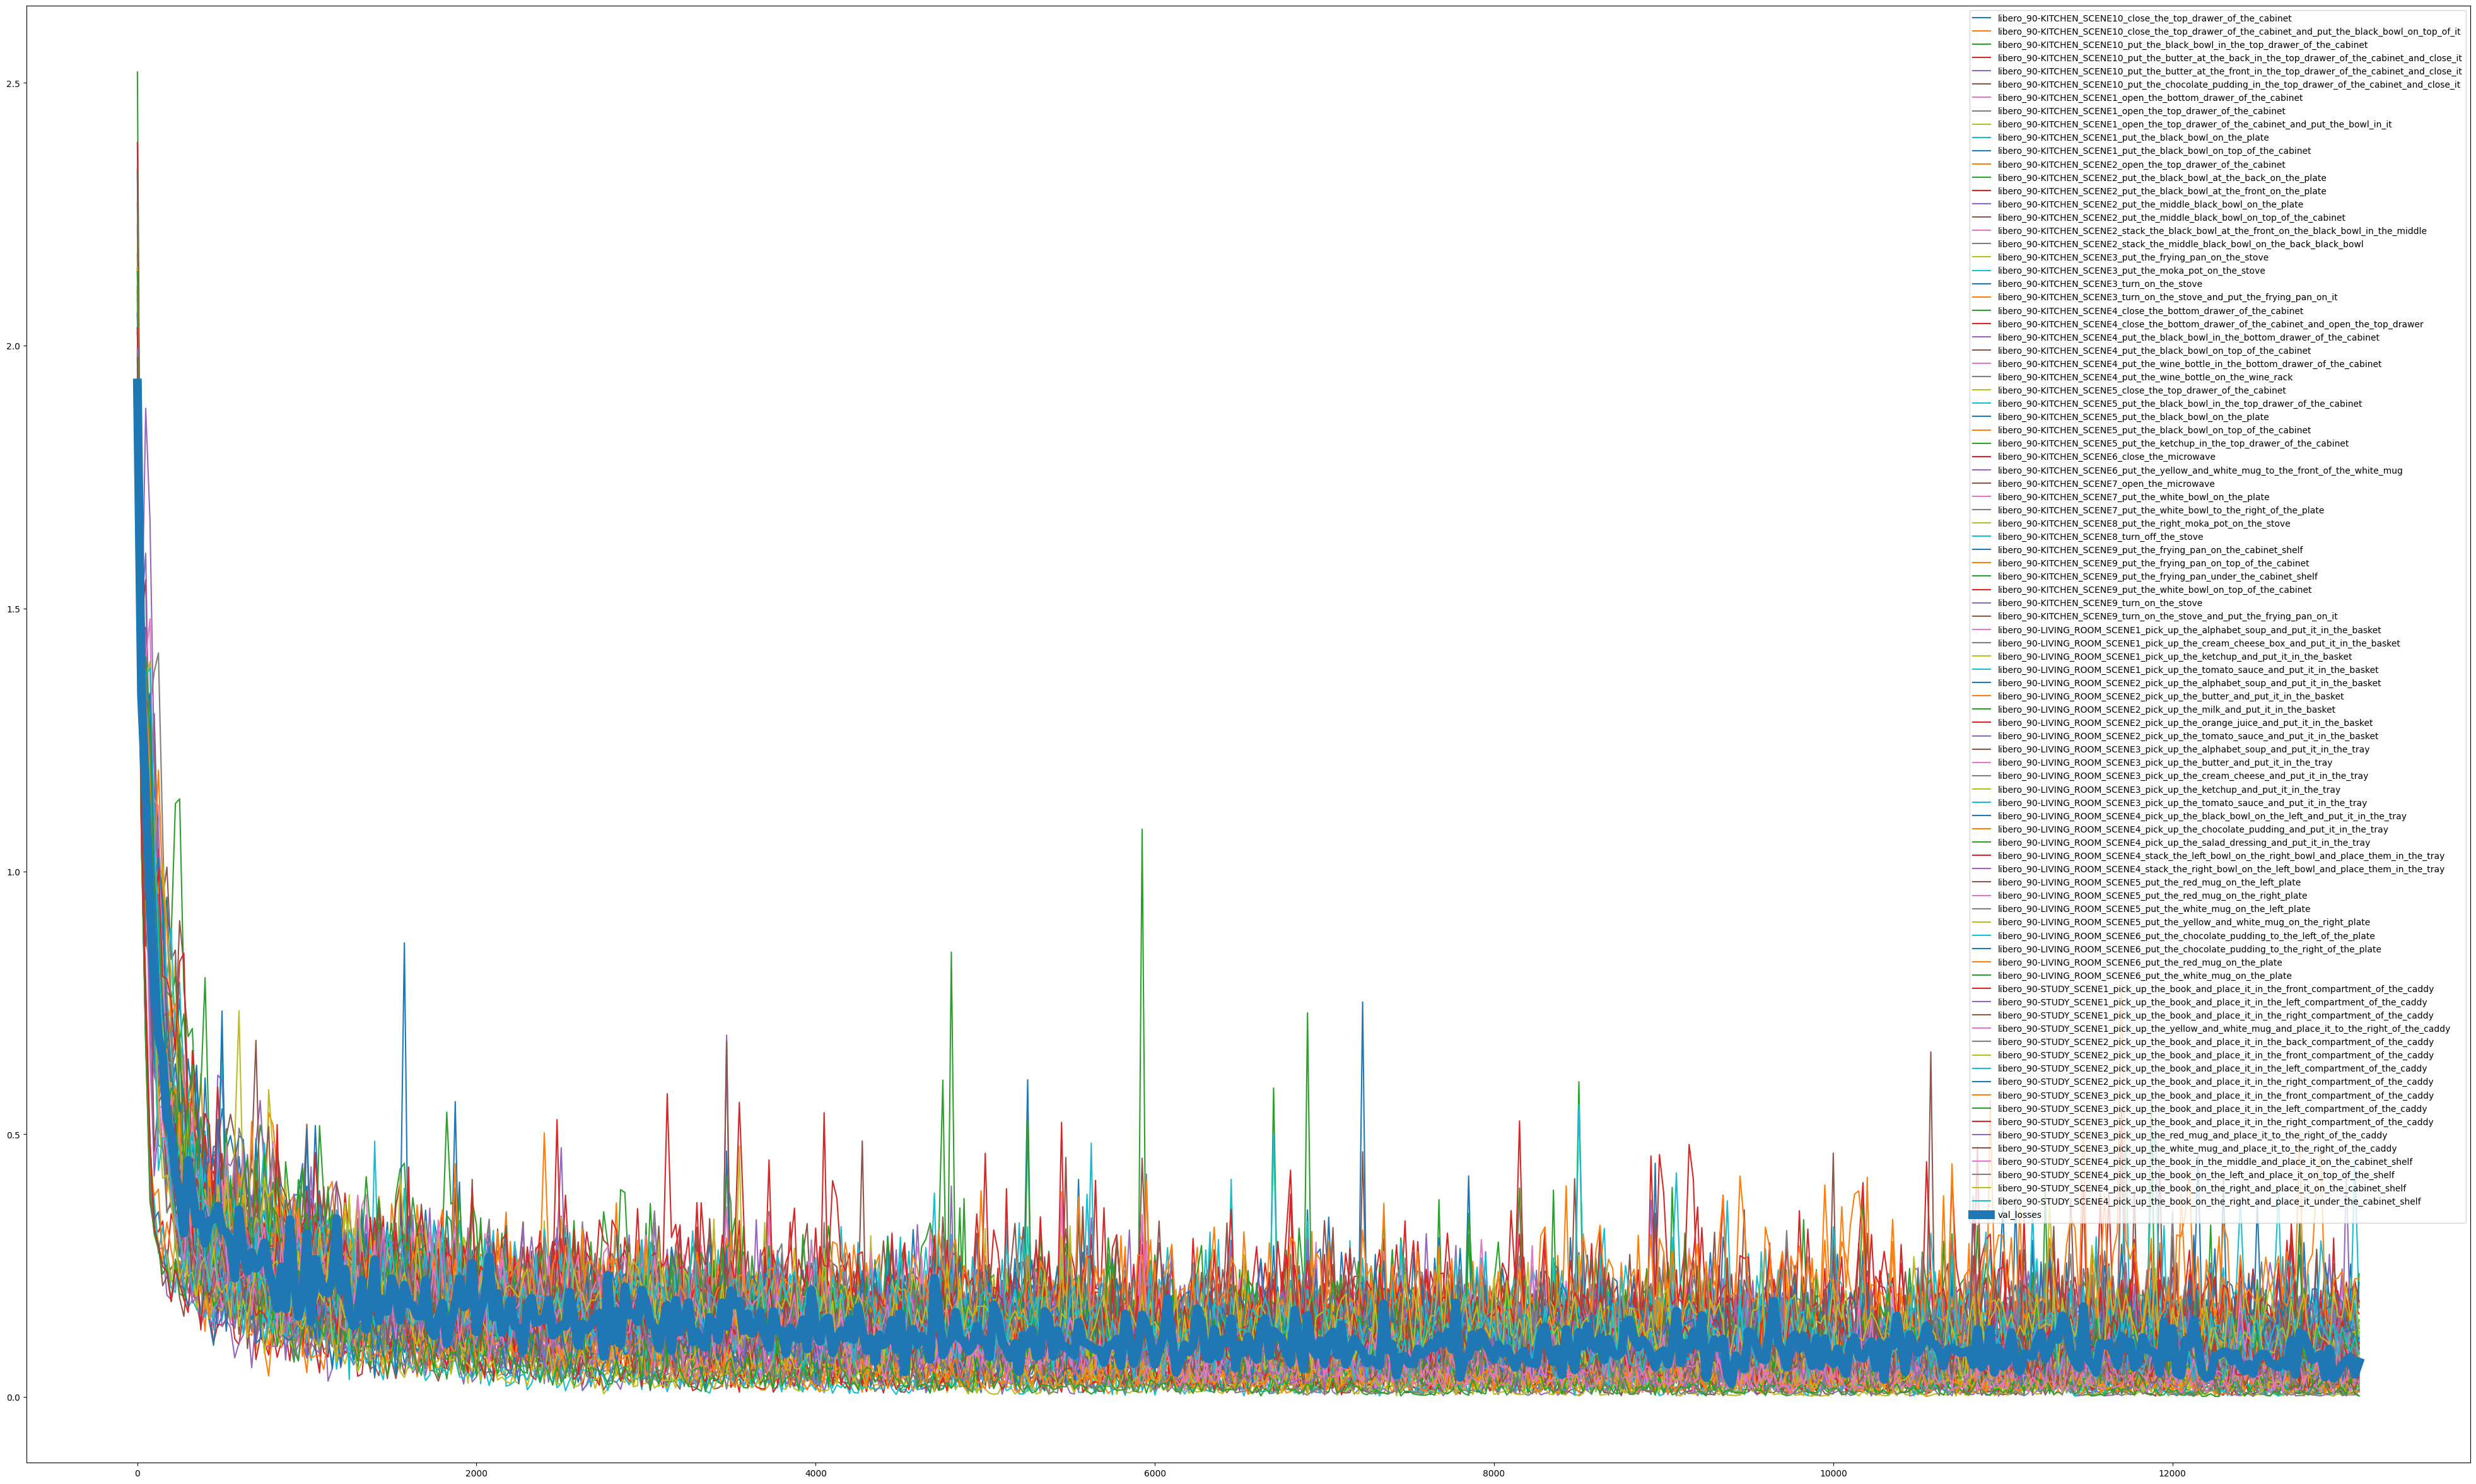

In [12]:
# val loss broken down
plt.figure(figsize=(50, 30))
val_data = plot_data['val_losses']
val_x = [x[0] for x in val_data]
val_y = [x[1] for x in val_data]
per_task_val_losses = plot_data['per_task_val_losses']
# Plot individual task lines with lower zorder
for task_name, task_losses in per_task_val_losses.items():
    task_x = [x[0] for x in task_losses]
    task_y = [x[1] for x in task_losses]
    plt.plot(task_x, task_y, label=task_name, zorder=1)

# Plot val_losses with higher zorder to ensure it's on top
plt.plot(val_x, val_y, label='val_losses', linewidth=10, zorder=10)
plt.legend()
plt.show()


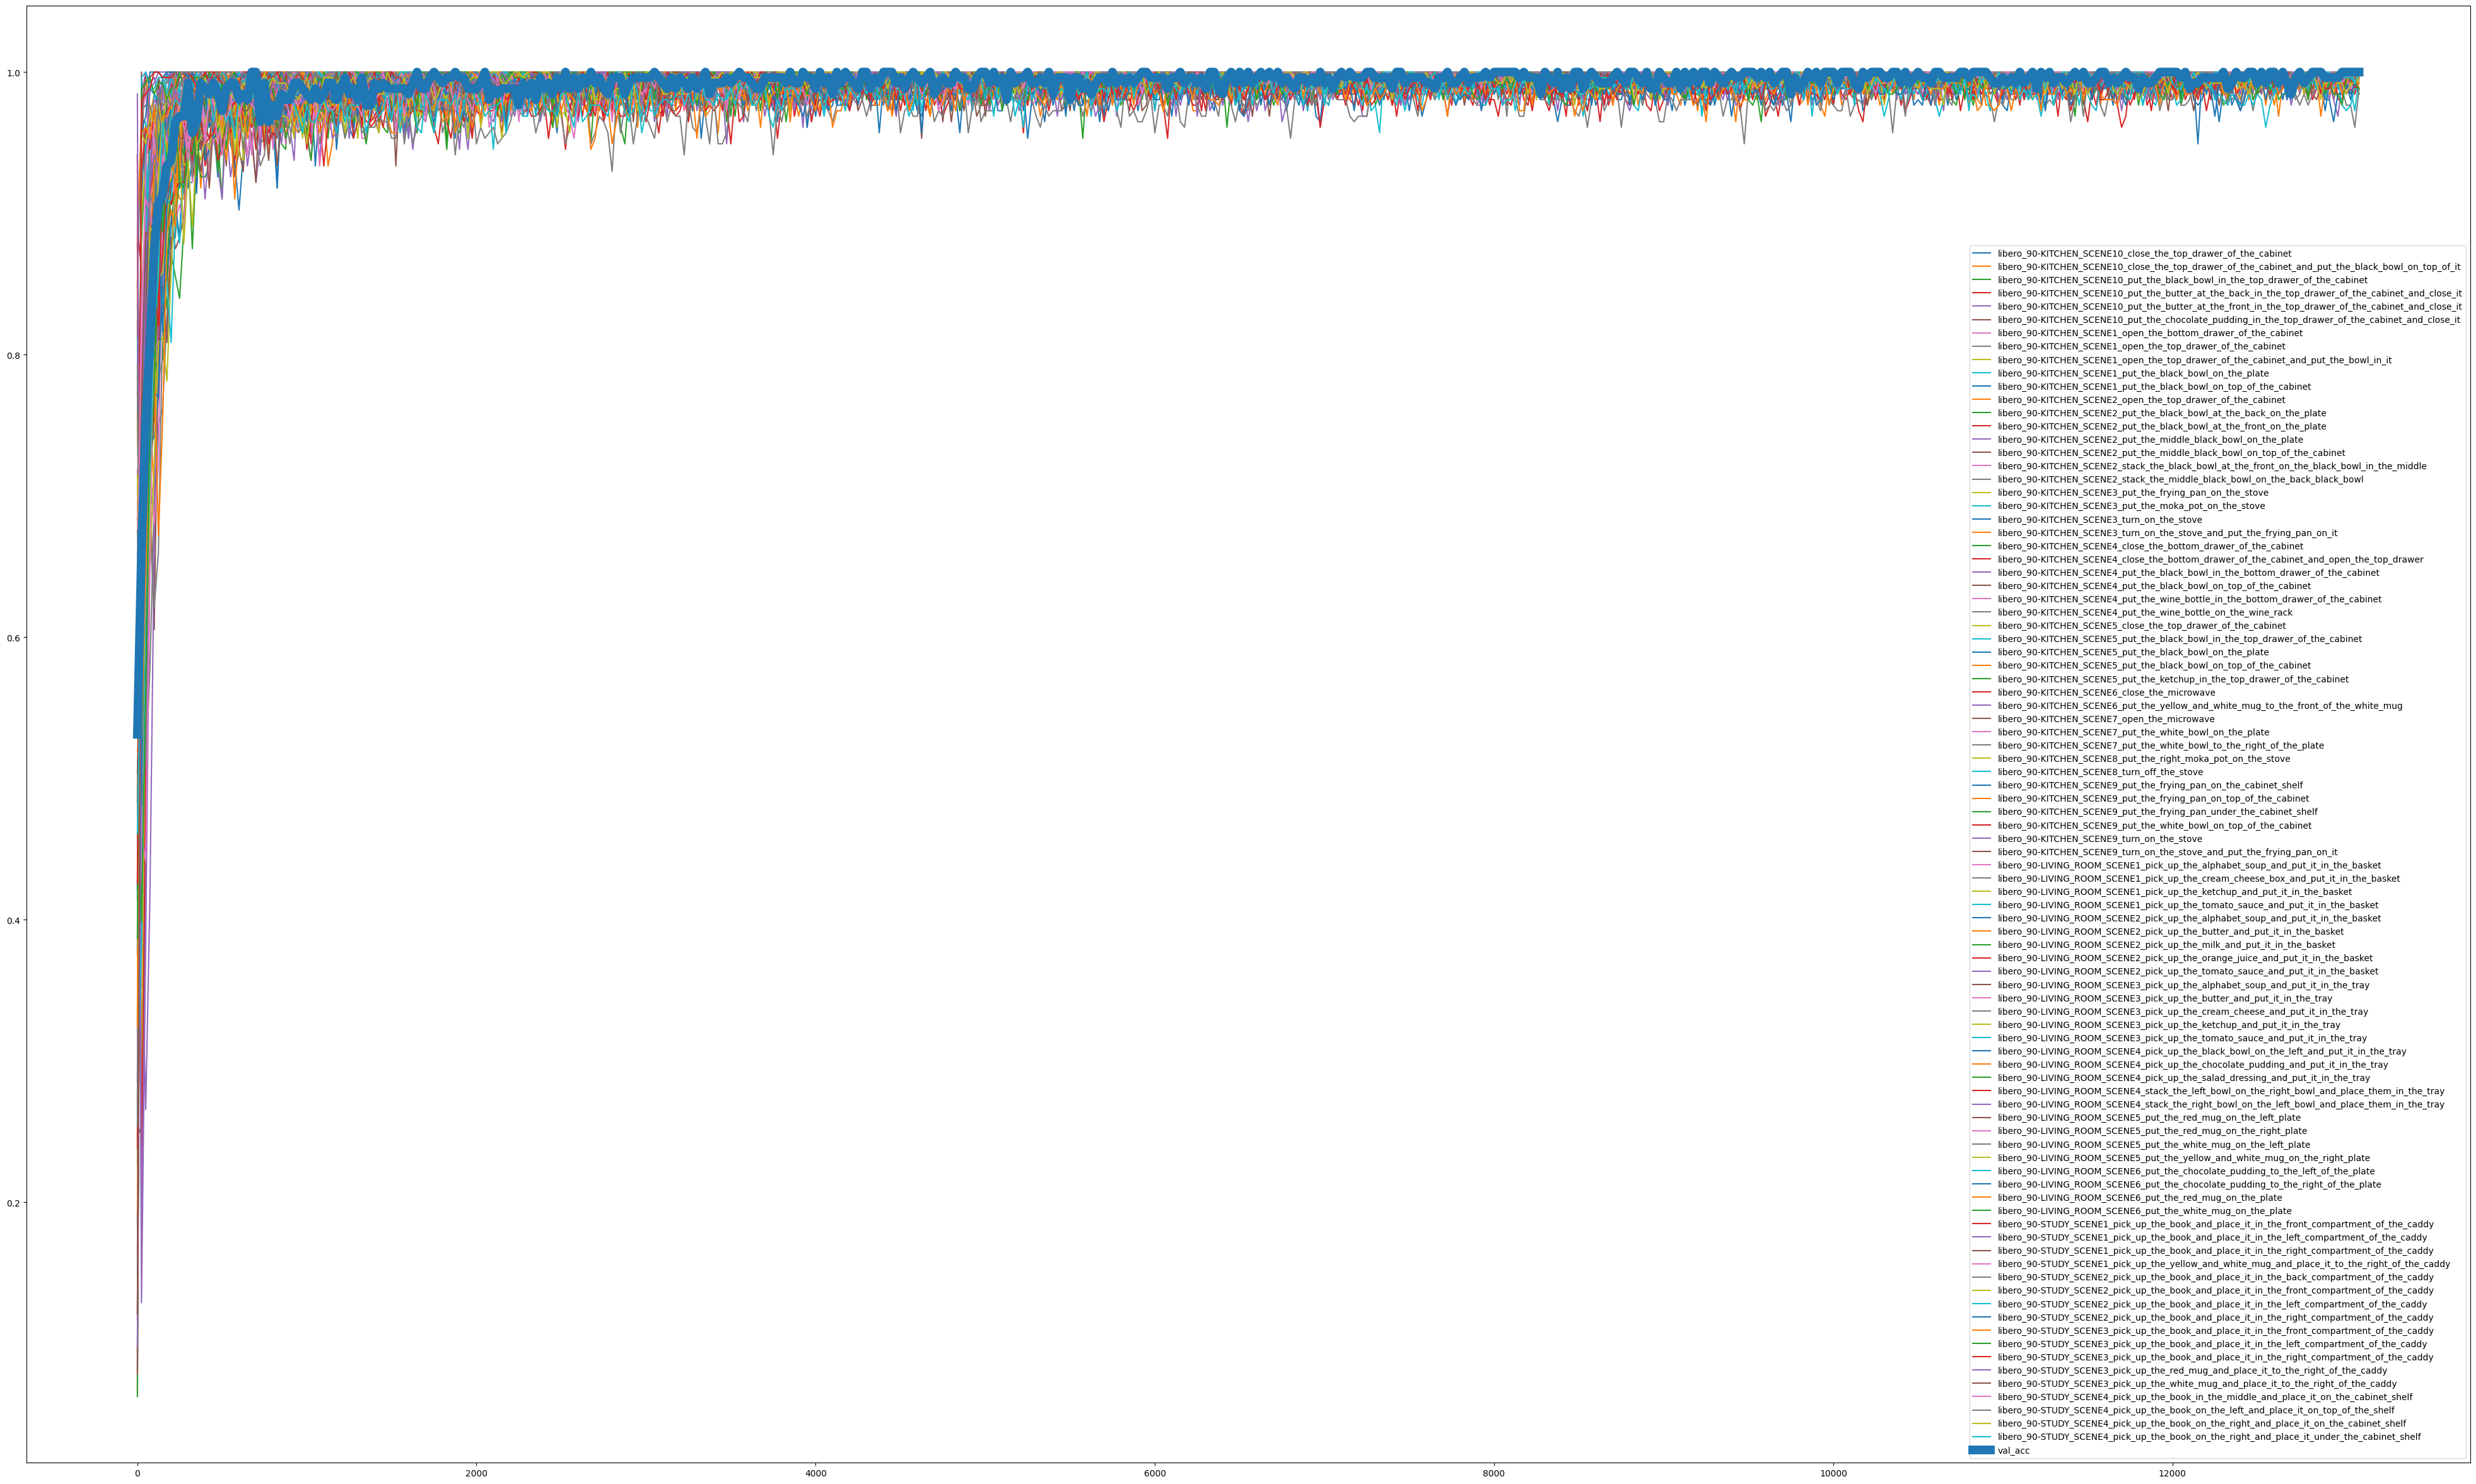

In [13]:
# val loss broken down
plt.figure(figsize=(50, 30))
val_acc = plot_data['val_accuracies']
val_x = [x[0] for x in val_acc]
val_y = [x[1] for x in val_acc]
per_task_val_acc = plot_data['per_task_val_accuracies']
# Plot individual task lines with lower zorder
for task_name, task_accuracies in per_task_val_acc.items():
    task_x = [x[0] for x in task_accuracies]
    task_y = [x[1] for x in task_accuracies]
    plt.plot(task_x, task_y, label=task_name, zorder=1)

# Plot val_losses with higher zorder to ensure it's on top
plt.plot(val_x, val_y, label='val_acc', linewidth=10, zorder=10)
plt.legend()
plt.show()


# Testing Through Time

In [20]:
from train_BERT_classifier import load_classifier

In [6]:
ckpt_num = 1310
network = load_classifier(root_path, ckpt_num)

In [ ]:
# set all params, and make the test_dataset
from envs.libero_utils import get_dataset as get_libero_dataset
import tqdm
import jax
import jax.numpy as jnp

SEED = 0
all_test_demo_nums = list(range(25, 50))
env_name = 'libero_90'
batch_size = 256
p_drop_state = 0.5
horizon_length = 5
discount = 0.99
task_name = ''
language_embedder = 'bert'
augmentation_type = 'none'
augmentation_reward = False
keys_to_load = ['agentview_rgb', 'eye_in_hand_rgb', 'language']
batch_level_sampling = True
all_test_dataset = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load, batch_level_sampling=batch_level_sampling, demo_nums_to_use_per_task=all_test_demo_nums, augmentation_dict=None)

In [18]:
# initialize, the other_lang_embeddings_map needed to determine accuracy()
import numpy as np
BERT_HIDDEN_DIM = 768
all_possible_lang_embeddings = set()
for i in tqdm.tqdm(range(10), desc="Sampling lang embeddings"):
    batch = all_test_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    for lang_embedding in batch['observations']['language']:
        lang_embedding = tuple(lang_embedding)
        all_possible_lang_embeddings.add(lang_embedding)
all_possible_lang_embeddings = [np.array(lang_embedding) for lang_embedding in all_possible_lang_embeddings]

other_lang_embeddings_map = {tuple(lang_embedding): [] for lang_embedding in all_possible_lang_embeddings}
for lang_embedding in tqdm.tqdm(other_lang_embeddings_map, total=len(other_lang_embeddings_map)):
    for other_lang_embedding in all_possible_lang_embeddings:
        if np.any(lang_embedding != other_lang_embedding):
            other_lang_embeddings_map[lang_embedding].append(other_lang_embedding)

NUM_TASKS = 74
assert len(other_lang_embeddings_map) == NUM_TASKS, f"Expected {NUM_TASKS} lang embeddings, got {len(other_lang_embeddings_map)}"
assert [len(x) == NUM_TASKS - 1 for x in other_lang_embeddings_map.values()], f"Expected {NUM_TASKS - 1} negative samples for each lang embedding, got {len(x)} for {lang_embedding}"

100%|██████████| 74/74 [00:00<00:00, 600.39it/s]


In [ ]:
# copying over loss and acc. functions used during training

def sample_negative_lang(batch, rng):
    """Sample negative embeddings - call BEFORE JIT-compiled functions."""
    lang_embedding = batch['observations']['language']
    batch_size = lang_embedding.shape[0]
    
    neg_embeddings = []
    for i in range(batch_size):
        key = tuple(np.array(lang_embedding[i]))
        candidates = other_lang_embeddings_map[key]
        idx = int(jax.random.randint(rng, (), 0, len(candidates)))
        rng, _ = jax.random.split(rng)
        neg_embeddings.append(candidates[idx])
    return jnp.array(neg_embeddings), rng

def get_loss_fn(batch, neg_lang, train, rng):    
    def loss_fn(grad_params):   
        masked_actions = batch['actions'] * batch['masks'][..., None]
        batch_actions = jnp.reshape(masked_actions, (masked_actions.shape[0], -1))
        pos_lang = batch['observations'].pop('language')  # (batch, 768)
        
        pos_rng, neg_rng = jax.random.split(rng)
        # Positive examples: correct (obs, action, lang) triplets
        pos_logits = network.select('classifier')(
            batch['observations'], batch_actions, pos_lang,
            params=grad_params, train=train, rng=pos_rng
        )  # (batch, 1)
        
        # Negative examples: use pre-sampled embeddings
        neg_logits = network.select('classifier')(
            batch['observations'], batch_actions, neg_lang,
            params=grad_params, train=train, rng=neg_rng
        )  # (batch, 1)
        
        # Binary cross-entropy: positives -> 1, negatives -> 0
        pos_loss = optax.sigmoid_binary_cross_entropy(pos_logits, jnp.ones_like(pos_logits))
        neg_loss = optax.sigmoid_binary_cross_entropy(neg_logits, jnp.zeros_like(neg_logits))
        classifier_loss = jnp.mean(pos_loss) + jnp.mean(neg_loss)
        
        return classifier_loss, {
            'classifier_loss': classifier_loss,
            'pos_loss': jnp.mean(pos_loss),
            'neg_loss': jnp.mean(neg_loss),
        }
    return loss_fn

def accuracy(network, batch, rng):
    neg_lang, rng = sample_negative_lang(batch, rng)
    
    pos_lang = batch['observations'].pop('language')
    batch_masked_actions = batch['actions'] * batch['masks'][..., None]
    batch_actions = jnp.reshape(batch_masked_actions, (batch_masked_actions.shape[0], -1))
    
    # Positive examples
    pos_logits = network.select('classifier')(
        batch['observations'], batch_actions, pos_lang,
        train=False, params=network.params
    )
    
    # Negative examples
    neg_logits = network.select('classifier')(
        batch['observations'], batch_actions, neg_lang,
        train=False, params=network.params
    )
    
    # Correct if model assigns higher score to true lang than sampled neg lang
    num_correct = jnp.sum(pos_logits > neg_logits)
    num_total = pos_logits.shape[0]
    
    return num_correct, num_total

In [23]:
network, hparams =  network

In [24]:
test_rng = jax.random.PRNGKey(SEED + 200)
num_test_steps = 5 * all_test_dataset.size // batch_size # dataset object is implemented as infinite, but 100 should be good enough w/ a batch size of 256
test_num_correct, test_num_total = 0, 0

# for i in tqdm.tqdm(range(num_test_steps), total=num_test_steps, desc="Testing"):
#     test_batch = all_test_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
#     this_test_rng, test_rng = jax.random.split(test_rng)
#     num_correct, num_total = accuracy(network, test_batch, this_test_rng)
#     test_num_correct += num_correct
#     test_num_total += num_total
# avg_test_acc = test_num_correct / test_num_total
# print(f"Test accuracy of {p_drop_state}: {avg_test_acc}, {test_num_correct}/{test_num_total}")

# testing time, first by simply calling on test-batches, then visualizing!!
num_test_steps = 50 # dataset is infinite, but 100 should be good enough w/ a batch size of 256
test_num_correct_zero_action, test_num_total_zero_action = 0, 0
for i in tqdm.tqdm(range(num_test_steps), total=num_test_steps, desc="Testing"):
    test_batch = all_test_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    # zero out both images before feeding into accuracy()
    # test_batch['observations']['agentview_rgb'] = jnp.zeros_like(test_batch['observations']['agentview_rgb'])
    # test_batch['observations']['eye_in_hand_rgb'] = jnp.zeros_like(test_batch['observations']['eye_in_hand_rgb'])
    # zero out action
    test_batch['actions'] = jnp.zeros_like(test_batch['actions'])    
    this_test_rng, test_rng = jax.random.split(test_rng)
    num_correct, num_total = accuracy(network, test_batch, this_test_rng)
    test_num_correct_zero_action += num_correct
    test_num_total_zero_action += num_total
avg_test_acc_zero_action = test_num_correct_zero_action / test_num_total_zero_action
print(f"Test accuracy with action zeroed out of {p_drop_state}: {avg_test_acc_zero_action}, {test_num_correct_zero_action}/{test_num_total_zero_action}")

Testing: 100%|██████████| 50/50 [00:36<00:00,  1.37it/s]

Test accuracy with action zeroed out of 0.5: 0.9642187356948853, 12342/12800


In [25]:
# now test over timestep
test_batch = all_test_dataset.sample_sequence(5, sequence_length=horizon_length, discount=discount)
original_lang_embedding = np.array(test_batch['observations']['language'])
other_embedding, test_rng = sample_negative_lang(test_batch, test_rng)
print(f"shape of original_lang_embedding: {original_lang_embedding.shape}, shape of other_embedding: {other_embedding.shape}")

masked_actions = test_batch['actions'] * test_batch['masks'][..., None]
batch_actions = jnp.reshape(masked_actions, (masked_actions.shape[0], -1))
pos_logits = network.select('classifier')(test_batch['observations'], batch_actions, original_lang_embedding, train=False, params=network.params)
neg_logits = network.select('classifier')(test_batch['observations'], batch_actions, other_embedding, train=False, params=network.params)
print(f"Pos logits: {pos_logits}, Neg logits: {neg_logits}")
print(f"Pos logits shape: {pos_logits.shape}, Neg logits shape: {neg_logits.shape}")

shape of original_lang_embedding: (5, 768), shape of other_embedding: (5, 768)
Pos logits: [[3.8642192]
 [4.0097103]
 [2.8769581]
 [4.4207907]
 [4.8083186]], Neg logits: [[-6.2530107]
 [-2.8311958]
 [-6.325694 ]
 [-4.766401 ]
 [-5.835886 ]]
Pos logits shape: (5, 1), Neg logits shape: (5, 1)


In [ ]:
# testing across time!
# combine val and test datasets
T = 85
regular_predictions_acc = []
zero_action_predictions_acc = []
zero_image_predictions_acc = []
zero_eye_in_hand_predictions_acc = []
zero_agentview_image_predictions_acc = []
import copy
for i in tqdm.tqdm(range(T), desc="Testing over timesteps", total=T):
    test_batch = all_test_dataset.sample_sequence_at_trajectory_position(batch_size, horizon_length, discount, position=i)
    test_batch_copy = copy.deepcopy(test_batch)
    test_batch_copy_2 = copy.deepcopy(test_batch)
    # test_batch_copy_3 = copy.deepcopy(test_batch)
    # test_batch_copy_4 = copy.deepcopy(test_batch)
    test_rng, this_test_rng_1, this_test_rng_2, this_test_rng_3, this_test_rng_4, this_test_rng_5 = jax.random.split(test_rng, 6)

    # visualize the first image in test_batch
    # im = test_batch['observations']['agentview_rgb'][0][::-1, ::-1, :]
    # plt.imshow(im)
    # plt.title(f"Task {test_batch['observations']['language'][0].argmax()}, timestep {i}")
    # plt.show()

    # no zeroing out
    num_correct, num_total = accuracy(network, test_batch, this_test_rng_1)
    regular_predictions_acc.append(num_correct / num_total)
    
    test_batch_copy['actions'] = jnp.zeros_like(test_batch_copy['actions'])
    num_correct, num_total = accuracy(network, test_batch_copy, this_test_rng_2)
    zero_action_predictions_acc.append(num_correct / num_total)

    # zeroing out images not actions
    test_batch_copy_2['observations']['agentview_rgb'] = jnp.zeros_like(test_batch_copy_2['observations']['agentview_rgb'])
    test_batch_copy_2['observations']['eye_in_hand_rgb'] = jnp.zeros_like(test_batch_copy_2['observations']['eye_in_hand_rgb'])
    num_correct, num_total = accuracy(network, test_batch_copy_2, this_test_rng_3)
    zero_image_predictions_acc.append(num_correct / num_total)

    # # only zero out eye_in_hand_rgb
    # test_batch_copy_3['observations']['eye_in_hand_rgb'] = jnp.zeros_like(test_batch_copy_3['observations']['eye_in_hand_rgb'])
    # num_correct, num_total = accuracy(network, test_batch_copy_3, this_test_rng_4)
    # zero_eye_in_hand_predictions_acc.append(num_correct / num_total)

    # ## only zero out wrist image
    # test_batch_copy_4['observations']['agentview_rgb'] = jnp.zeros_like(test_batch_copy_4['observations']['agentview_rgb'])
    # num_correct, num_total = accuracy(network, test_batch_copy_4, this_test_rng_5)
    # zero_agentview_image_predictions_acc.append(num_correct / num_total)

    del test_batch, test_batch_copy

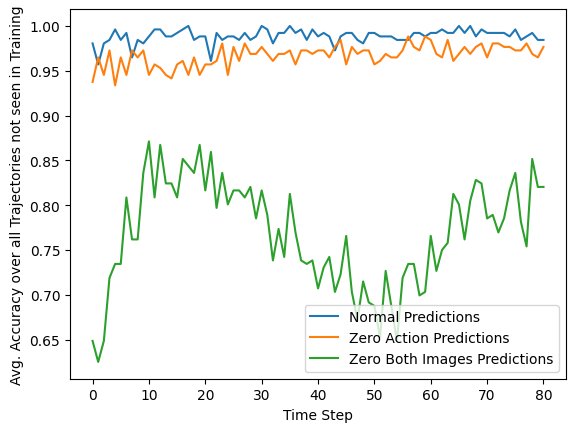

In [39]:
# line plot of normal_predictions_acc and zero_action_predictions_acc over time
plt.xlabel('Time Step')
plt.ylabel('Avg. Accuracy over all Trajectories not seen in Training')

plt.plot(regular_predictions_acc, label='Normal Predictions')
plt.plot(zero_action_predictions_acc, label='Zero Action Predictions')
plt.plot(zero_image_predictions_acc, label='Zero Both Images Predictions')
# plt.plot(zero_eye_in_hand_predictions_acc, label='Zero Wrist Image Predictions')
# plt.plot(zero_agentview_image_predictions_acc, label='Zero Agentview Image Predictions')
# plt.title(f"p_drop_state = {p_drop_state}; avg_test_acc = {avg_test_acc}; avg_test_acc_zero_action = {avg_test_acc_zero_action}")
plt.legend(loc='lower right')
plt.show()

In [34]:
batch['dataset_indices']

array([44, 72, 34, 69], dtype=int32)